In [12]:
!pip install statsmodels


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [14]:
data = [100, 110, 115, 130, 145, 160, 170]  # Example data
model = ARIMA(data, order=(2, 0, 0))  # p=2, d=0, q=0
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    7
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 -23.646
Date:                Thu, 17 Sep 2026   AIC                             55.292
Time:                        11:50:56   BIC                             55.075
Sample:                             0   HQIC                            52.617
                                  - 7                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        132.8314     26.692      4.977      0.000      80.517     185.146
ar.L1          1.7794      0.386      4.608      0.000       1.022       2.536
ar.L2         -0.8920      0.300     -2.974      0.0

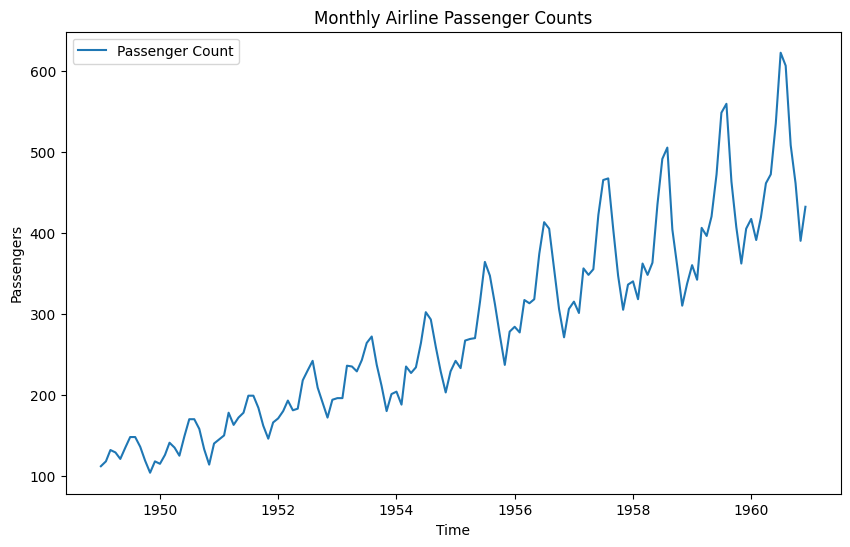

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -688.749
Date:                Thu, 17 Sep 2026   AIC                           1385.498
Time:                        11:50:57   BIC                           1397.349
Sample:                    01-01-1949   HQIC                          1390.313
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5724      0.097      5.928      0.000       0.383       0.762
ma.L1         -0.3126      0.098     -3.198      0.001      -0.504      -0.121
ma.L2         -0.5078      0.069     -7.412      0.0

c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [15]:
# Load dataset
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(data_url, parse_dates=['Month'], index_col='Month')

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.plot(data, label='Passenger Count')
plt.title('Monthly Airline Passenger Counts')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()
plt.show()

# Fit ARIMA model
model = ARIMA(data['Passengers'], order=(1, 1, 2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

In [16]:
# Apply first-order differencing
# data_diff = data['Passengers'].diff().dropna()

# # Re-check stationarity
# result_diff = adfuller(data_diff)
# print("ADF Statistic (Differenced):", result_diff[0])
# print("p-value (Differenced):", result_diff[1])

# # Visualize differenced data
# plt.figure(figsize=(10, 6))
# plt.plot(data_diff, label='Differenced Data')
# plt.legend()
# plt.title('First-Order Differencing')
# plt.show()

In [17]:
# Residual diagnostics
# residuals = model_fit.resid

# plt.figure(figsize=(10, 6))
# plt.plot(residuals, label='Residuals')
# plt.title('Residuals')
# plt.legend()
# plt.show()

# residuals.plot(kind='kde', title='Residual Distribution')
# plt.show()

c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -688.749
Date:                Thu, 17 Sep 2026   AIC                           1385.498
Time:                        11:50:58   BIC                           1397.349
Sample:                    01-01-1949   HQIC                          1390.313
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5724      0.097      5.928      0.000       0.383       0.762
ma.L1         -0.3126      0.098     -3.198      0.001      -0.504      -0.121
ma.L2         -0.5078      0.069     -7.412      0.0

C:\Users\Hait\AppData\Local\Temp\ipykernel_14220\973868766.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=data.index[-1], periods=12, freq='M')


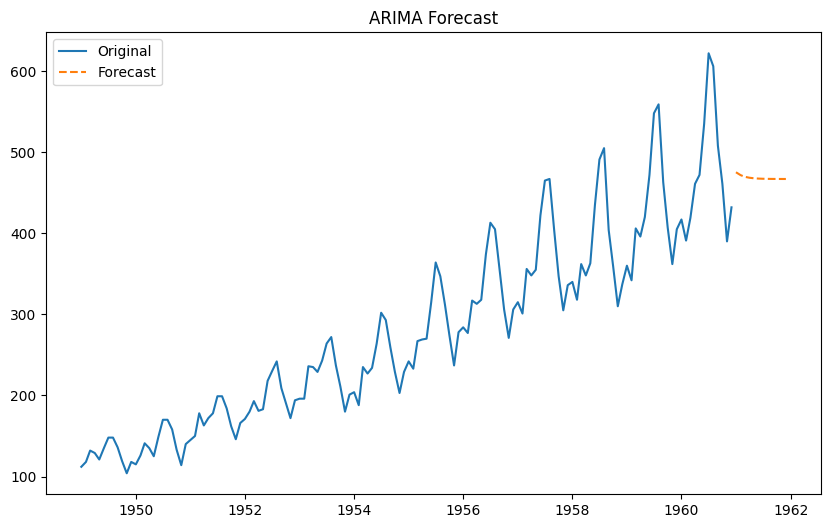

In [18]:
# Fit ARIMA model
model = ARIMA(data['Passengers'], order=(1, 1, 2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=12)
forecast_index = pd.date_range(start=data.index[-1], periods=12, freq='M')

# Visualize forecast
plt.figure(figsize=(10, 6))
plt.plot(data, label='Original')
plt.plot(forecast_index, forecast, label='Forecast', linestyle='--')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()